# 13 — Test adverse : l'IDE se sature sans coût

L'[audit critique](../docs/limites.md) relève une objection que le reste du dépôt n'avait pas
traitée. Une plateforme contrainte de maintenir un IDE élevé peut servir des contenus
**formellement divergents mais substantiellement vides** — un article étiqueté « point de vue
opposé » dont le propos reste adjacent à celui du lecteur. Si l'index se sature ainsi, il est
inutilisable comme norme.

C'est un problème d'optimisation sous contrainte : **aucune donnée réelle n'est nécessaire
pour le trancher**, et il valait mieux le trancher avant de proposer un seuil réglementaire.

**Ce que ce notebook établit :**

* l'objection est **fondée**, et sévèrement. Une plateforme qui peut dissocier l'étiquette du
  contenu obtient un **IDE de 1,000 — la note parfaite — pour une diversité de contenu
  strictement nulle**, et sans perdre un point d'engagement ;
* il n'est même pas besoin d'aller jusque-là : à mi-découplage, la contrainte n'a plus que
  **36 % de sa force** initiale ;
* l'**entropie quadratique de Rao** résiste, et mieux qu'attendu : au-delà d'un découplage de
  moitié, le plancher devient purement **inatteignable** — la plateforme ne peut plus s'y
  conformer sans diversifier réellement ;
* et l'écart entre les deux indices, mesuré contre sa contrefactuelle honnête, fournit une
  **signature de manipulation** directement prescriptible.

## 1. Le modèle, et ce qu'il met en jeu

Un catalogue de $k$ points de vue, de positions canoniques $c_\ell$ réparties sur un axe
d'opinion. Un lecteur en $u$. L'engagement décroît avec la distance au lecteur :

$$g(x) = \exp\left(-\frac{(x-u)^2}{2w^2}\right)$$

C'est l'hypothèse de bulle, et elle est **défavorable à la plateforme** : elle suppose que
conforter paie. Sans elle, il n'y aurait pas de conflit entre diversité et profit, donc pas de
question.

Le **découplage** $\varphi \in [0,1]$ mesure la latitude de la plateforme à dissocier
l'étiquette du contenu. Le meilleur article portant l'étiquette $\ell$ se trouve en

$$x^*_\ell = c_\ell + \varphi\,(u - c_\ell)$$

À $\varphi = 0$ l'étiquette prédit le contenu. À $\varphi = 1$, toute étiquette est disponible
en version vide, arbitrairement proche du lecteur. C'est là, et nulle part ailleurs, que se
joue la manipulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.gaming import (
    canonical_positions,
    engagement,
    excess_signature,
    optimal_feed_under_ide,
    optimal_feed_under_rao,
    served_positions,
)
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

VIEWPOINTS = 8      # points de vue du catalogue réglementaire
USER = 0.6          # position du lecteur, décentrée : la bulle a un côté
WIDTH = 0.5         # largeur d'engagement
FLOOR = 0.80        # plancher d'IDE de référence

canonical = canonical_positions(VIEWPOINTS)
print(f"catalogue de {VIEWPOINTS} points de vue :")
print("  positions canoniques  " + "  ".join(f"{c:+.2f}" for c in canonical))
print(f"  lecteur en {USER:+.2f}\n")

for decoupling in (0.0, 0.5, 1.0):
    served = served_positions(canonical, USER, decoupling)
    print(f"  φ = {decoupling:.1f}  contenus servis  " + "  ".join(f"{x:+.2f}" for x in served))

catalogue de 8 points de vue :
  positions canoniques  -1.00  -0.71  -0.43  -0.14  +0.14  +0.43  +0.71  +1.00
  lecteur en +0.60

  φ = 0.0  contenus servis  -1.00  -0.71  -0.43  -0.14  +0.14  +0.43  +0.71  +1.00
  φ = 0.5  contenus servis  -0.20  -0.06  +0.09  +0.23  +0.37  +0.51  +0.66  +0.80
  φ = 1.0  contenus servis  +0.60  +0.60  +0.60  +0.60  +0.60  +0.60  +0.60  +0.60


## 2. Un plancher d'entropie est une température

La plateforme maximise $\sum_\ell q_\ell\,g(x^*_\ell)$ sous $\mathrm{IDE}(q) \geq \tau$. Le
maximum d'une forme linéaire à entropie fixée est une distribution de Boltzmann :

$$q_\ell \propto \exp\big(g(x^*_\ell)/T\big)$$

où $T$ est le multiplicateur qui sature le plancher. **La contrainte réglementaire agit
exactement comme la température sociale du reste du dépôt.** Ce n'est pas une analogie : c'est
la même algèbre, et elle rend la solution exacte plutôt qu'approchée — ce qui importe pour un
résultat négatif, où une heuristique de solveur pourrait porter la conclusion.

Première vérification : la plateforme **sature** le plancher, elle ne le dépasse jamais.

In [2]:
print(f"{'plancher τ':>11s} {'IDE atteint':>13s} {'engagement':>12s} {'étiquettes servies':>22s}")
print("-" * 62)
for floor in (0.0, 0.3, 0.5, 0.8, 0.95, 1.0):
    feed = optimal_feed_under_ide(VIEWPOINTS, USER, floor=floor, width=WIDTH)
    spread = int(np.sum(feed.weights > 0.01))
    print(f"{floor:11.2f} {feed.ide:13.3f} {feed.engagement:12.3f} {spread:19d} / {VIEWPOINTS}")

print("\nÀ τ = 0 la plateforme sert son unique meilleur contenu ; à τ = 1, l'uniforme.")
print("Entre les deux, elle atteint exactement la contrainte — jamais davantage.")

 plancher τ   IDE atteint   engagement     étiquettes servies
--------------------------------------------------------------
       0.00         0.000        0.974                   1 / 8
       0.30         0.300        0.964                   2 / 8
       0.50         0.500        0.931                   4 / 8
       0.80         0.800        0.798                   8 / 8
       0.95         0.950        0.643                   8 / 8
       1.00         1.000        0.474                   8 / 8

À τ = 0 la plateforme sert son unique meilleur contenu ; à τ = 1, l'uniforme.
Entre les deux, elle atteint exactement la contrainte — jamais davantage.


## 3. Sur un catalogue honnête, la contrainte coûte

C'est la vérification qui rend le test adverse non trivial. Si le plancher ne coûtait rien même
sans manipulation, il n'y aurait rien à saturer et le résultat serait vide.

In [3]:
free_honest = optimal_feed_under_ide(VIEWPOINTS, USER, floor=0.0, width=WIDTH).engagement

print(f"{'plancher':>9s} {'engagement':>12s} {'coût':>8s}")
print("-" * 31)
for floor in (0.5, 0.7, 0.8, 0.9, 0.95, 1.0):
    feed = optimal_feed_under_ide(VIEWPOINTS, USER, floor=floor, width=WIDTH)
    cost = 1.0 - feed.engagement / free_honest
    print(f"{floor:9.2f} {feed.engagement:12.3f} {100 * cost:7.1f} %")

print("\nUn plancher d'IDE à 0,80 coûte 18 % d'engagement à une plateforme honnête.")
print("La contrainte mord. Reste à savoir si elle mord une plateforme qui triche.")

 plancher   engagement     coût
-------------------------------
     0.50        0.931     4.4 %
     0.70        0.858    12.0 %
     0.80        0.798    18.1 %
     0.90        0.710    27.1 %
     0.95        0.643    34.0 %
     1.00        0.474    51.4 %

Un plancher d'IDE à 0,80 coûte 18 % d'engagement à une plateforme honnête.
La contrainte mord. Reste à savoir si elle mord une plateforme qui triche.


## 4. Le test adverse

Même plancher, même catalogue réglementaire — mais la plateforme peut désormais faire porter
une étiquette éloignée par un contenu proche.

In [4]:
DECOUPLINGS = (0.0, 0.25, 0.5, 0.75, 1.0)

baselines = {
    d: optimal_feed_under_ide(VIEWPOINTS, USER, floor=0.0, decoupling=d, width=WIDTH).engagement
    for d in DECOUPLINGS
}

print("coût du plancher d'IDE, en % d'engagement perdu")
print(f"{'plancher':>9s}" + "".join(f"{f'φ = {d:.2f}':>11s}" for d in DECOUPLINGS))
print("-" * 64)
for floor in (0.5, 0.7, 0.8, 0.9, 0.95, 1.0):
    row = ""
    for d in DECOUPLINGS:
        feed = optimal_feed_under_ide(VIEWPOINTS, USER, floor=floor, decoupling=d, width=WIDTH)
        row += f"{100 * (1 - feed.engagement / baselines[d]):10.1f}%"
    print(f"{floor:9.2f}" + row)

coût du plancher d'IDE, en % d'engagement perdu
 plancher   φ = 0.00   φ = 0.25   φ = 0.50   φ = 0.75   φ = 1.00
----------------------------------------------------------------
     0.50       4.4%       2.6%       1.2%       0.3%       0.0%
     0.70      12.0%       7.8%       3.8%       1.0%       0.0%
     0.80      18.1%      12.5%       6.6%       1.8%       0.0%
     0.90      27.1%      20.0%      11.4%       3.4%       0.0%
     0.95      34.0%      25.9%      15.4%       4.8%       0.0%
     1.00      51.4%      41.4%      26.4%       8.7%       0.0%


### Le résultat, en une ligne

La dernière colonne est **zéro partout**, y compris pour un plancher d'IDE de 1,00 — la note
maximale. Une plateforme qui peut découpler entièrement l'étiquette du contenu obtient la
diversité parfaite sans céder un point d'engagement.

Regardons ce que ce fil contient réellement.

In [5]:
print(f"{'φ':>6s} {'IDE':>8s} {'Rao':>8s} {'écart':>8s} {'engagement':>12s} {'coût':>8s}")
print("-" * 54)
for d in DECOUPLINGS:
    feed = optimal_feed_under_ide(VIEWPOINTS, USER, floor=FLOOR, decoupling=d, width=WIDTH)
    cost = 100 * (1 - feed.engagement / baselines[d])
    print(f"{d:6.2f} {feed.ide:8.3f} {feed.rao:8.3f} {feed.signature:8.3f}"
          f" {feed.engagement:12.3f} {cost:7.1f} %")

print("\nÀ φ = 1 : IDE = 1,000 — la note parfaite — pour une diversité de contenu de 0,000.")
print("L'index décerne son meilleur score à un fil qui ne contient qu'un seul point de vue.")

     φ      IDE      Rao    écart   engagement     coût
------------------------------------------------------
  0.00    0.800    0.443    0.357        0.798    18.1 %
  0.25    0.800    0.324    0.476        0.862    12.5 %
  0.50    0.800    0.215    0.585        0.928     6.6 %
  0.75    0.800    0.108    0.692        0.980     1.8 %
  1.00    1.000    0.000    1.000        1.000     0.0 %

À φ = 1 : IDE = 1,000 — la note parfaite — pour une diversité de contenu de 0,000.
L'index décerne son meilleur score à un fil qui ne contient qu'un seul point de vue.


### Et il n'est pas besoin d'aller au bout

Le découplage complet est une caricature : aucune plateforme ne peut vider toutes ses
étiquettes. La question qui compte pour un régulateur est **à quelle vitesse la contrainte perd
sa force**.

In [6]:
reference_cost = 1 - optimal_feed_under_ide(
    VIEWPOINTS, USER, floor=FLOOR, decoupling=0.0, width=WIDTH
).engagement / baselines[0.0]

print(f"{'φ':>6s} {'coût':>8s} {'force restante':>16s}")
print("-" * 32)
for d in np.linspace(0.0, 1.0, 11):
    free = optimal_feed_under_ide(
        VIEWPOINTS, USER, floor=0.0, decoupling=float(d), width=WIDTH
    ).engagement
    feed = optimal_feed_under_ide(
        VIEWPOINTS, USER, floor=FLOOR, decoupling=float(d), width=WIDTH
    )
    cost = 1 - feed.engagement / free
    print(f"{d:6.1f} {100 * cost:7.1f} % {100 * cost / reference_cost:14.1f} %")

print("\nÀ mi-découplage la contrainte n'a plus que 36 % de sa force ;")
print("à φ = 0,8, il en reste 7 %. La dégradation est bien plus rapide que le découplage.")

     φ     coût   force restante
--------------------------------
   0.0    18.1 %          100.0 %
   0.1    16.0 %           88.2 %
   0.2    13.7 %           75.7 %
   0.3    11.3 %           62.6 %
   0.4     8.9 %           49.4 %
   0.5     6.6 %           36.5 %
   0.6     4.5 %           24.6 %
   0.7     2.6 %           14.4 %
   0.8     1.2 %            6.6 %
   0.9     0.3 %            1.7 %
   1.0     0.0 %            0.0 %

À mi-découplage la contrainte n'a plus que 36 % de sa force ;
à φ = 0,8, il en reste 7 %. La dégradation est bien plus rapide que le découplage.


## 5. L'entropie quadratique de Rao résiste

$$Q = \frac{2}{D}\sum_{\ell m} q_\ell q_m \, |x^*_\ell - x^*_m|$$

Elle ne compte pas les étiquettes, elle compte les **écarts entre contenus servis**, rapportés
à l'étendue $D$ du catalogue de référence.

!!! danger "Un piège de normalisation, et ce qu'il aurait coûté"
    Une première version de ce module normalisait $Q$ par l'étalement **effectivement servi**.
    La mesure devenait alors invariante d'échelle, et un fil réduit à un point y marquait
    $Q \approx 1$ sur du bruit d'arrondi. Le notebook aurait conclu que l'entropie de Rao est
    manipulable elle aussi — c'est-à-dire l'inverse de la vérité. L'unité est donc l'étendue
    du catalogue **de référence**, fixée par le régulateur.

In [7]:
free_rao = {
    d: optimal_feed_under_rao(VIEWPOINTS, USER, floor=0.0, decoupling=d, width=WIDTH).engagement
    for d in DECOUPLINGS
}

RAO_FLOOR = 0.50
print(f"plancher de Rao à {RAO_FLOOR:.2f}\n")
print(f"{'φ':>6s} {'Q atteignable':>15s} {'Q servi':>9s} {'conforme':>10s} {'coût':>9s}")
print("-" * 54)
for d in DECOUPLINGS:
    feed = optimal_feed_under_rao(VIEWPOINTS, USER, floor=RAO_FLOOR, decoupling=d, width=WIDTH)
    complies = feed.rao >= RAO_FLOOR - 1e-6
    cost = f"{100 * (1 - feed.engagement / free_rao[d]):7.1f} %" if complies else "     —"
    print(f"{d:6.2f} {feed.reachable_rao:15.3f} {feed.rao:9.3f} "
          f"{'oui' if complies else 'NON':>10s} {cost:>9s}")

plancher de Rao à 0.50

     φ   Q atteignable   Q servi   conforme      coût
------------------------------------------------------
  0.00           1.000     0.500        oui    15.6 %
  0.25           0.750     0.500        oui    21.1 %


  0.50           0.500     0.500        oui    39.5 %


  0.75           0.250     0.250        NON         —


  1.00           0.000     0.000        NON         —


### Deux propriétés, et la seconde est inattendue

**Le plancher devient inatteignable.** Au-delà d'un découplage de moitié, aucune distribution
d'étiquettes ne permet de satisfaire $Q \geq 0{,}5$ : la plateforme qui a vidé ses étiquettes
**ne peut plus se conformer**, quoi qu'elle fasse. Là où l'IDE offrait une échappatoire
gratuite, l'entropie de Rao ferme la porte.

**Et le coût augmente avec le découplage**, au lieu de diminuer : 16 % à $\varphi = 0$, 40 % à
$\varphi = 0{,}5$. C'est exactement l'inverse du comportement de l'IDE, et la raison en est
mécanique — vider ses étiquettes réduit la diversité atteignable, donc rend la conformité plus
chère. **Manipuler l'étiquetage se retourne contre la plateforme.**

C'est cette propriété, plus que la simple résistance, qui fait de $Q$ une norme tenable.

## 6. Une signature de manipulation, sans seuil inventé

L'écart brut $\mathrm{IDE} - Q$ n'est **pas** interprétable seul : les deux indices ne sont pas
sur la même échelle, et un fil parfaitement honnête en affiche déjà 0,36. Publier un seuil
là-dessus reviendrait à fabriquer un chiffre — ce que ce dépôt a déjà eu à retirer une fois.

La grandeur interprétable est la **différence à la contrefactuelle honnête** : ce qu'un
catalogue dont les étiquettes prédisent le contenu afficherait au même IDE. Elle vaut zéro par
construction pour une plateforme honnête, et elle est calculable par le régulateur puisqu'elle
ne dépend que du catalogue de référence, qu'il fixe lui-même.

In [8]:
print(f"{'φ':>6s} {'écart brut':>12s} {'excès':>9s}")
print("-" * 29)
for d in DECOUPLINGS:
    feed = optimal_feed_under_ide(VIEWPOINTS, USER, floor=FLOOR, decoupling=d, width=WIDTH)
    print(f"{d:6.2f} {feed.signature:12.3f} "
          f"{excess_signature(VIEWPOINTS, USER, FLOOR, d, WIDTH):9.3f}")

print("\nL'excès est nul pour une plateforme honnête et croît de façon monotone.")
print("C'est la seule des trois grandeurs qui soit directement prescriptible.")

     φ   écart brut     excès
-----------------------------
  0.00        0.357     0.000
  0.25        0.476     0.119
  0.50        0.585     0.228
  0.75        0.692     0.335
  1.00        1.000     0.643

L'excès est nul pour une plateforme honnête et croît de façon monotone.
C'est la seule des trois grandeurs qui soit directement prescriptible.


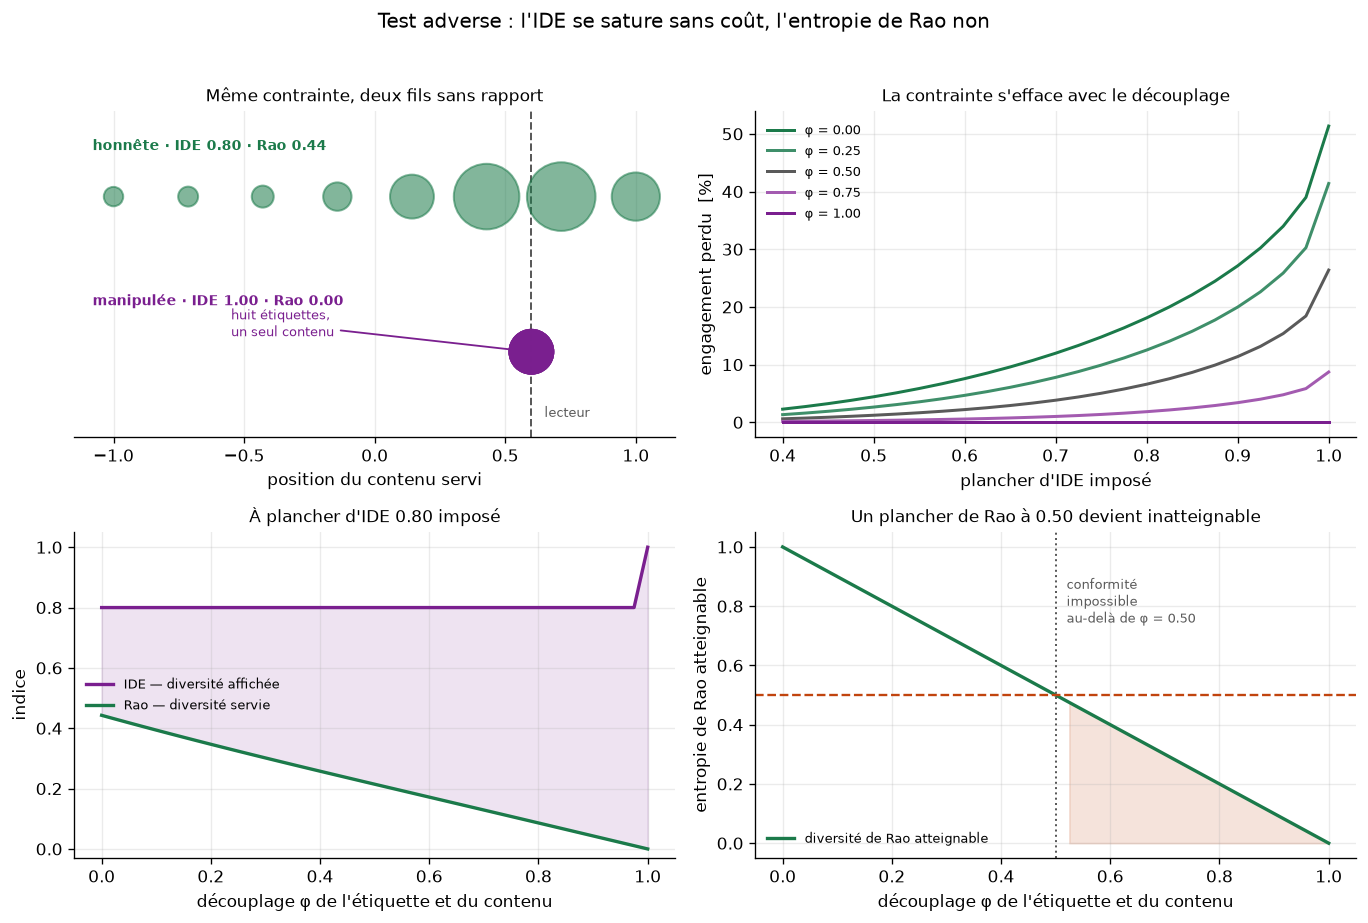

In [9]:
figure, axes = plt.subplots(2, 2, figsize=(11.5, 7.8))
served, cost_curve, scissors, resistance = axes.ravel()

honest = optimal_feed_under_ide(VIEWPOINTS, USER, floor=FLOOR, decoupling=0.0, width=WIDTH)
gamed = optimal_feed_under_ide(VIEWPOINTS, USER, floor=FLOOR, decoupling=1.0, width=WIDTH)

# (a) Ce que les deux plateformes servent réellement, sur deux rangs.
for row, (feed, colour, name) in enumerate(
    [(gamed, PALETTE["field"], "manipulée"), (honest, PALETTE["remedy"], "honnête")]
):
    served.scatter(feed.positions, np.full(VIEWPOINTS, row),
                   s=40 + 5200 * feed.weights, color=colour, alpha=0.55,
                   edgecolors=colour, linewidths=1.2, zorder=3)
    served.text(-1.08, row + 0.30, f"{name} · IDE {feed.ide:.2f} · Rao {feed.rao:.2f}",
                fontsize=8.5, color=colour, fontweight="bold")
served.axvline(USER, color=PALETTE["neutral"], linestyle="--", linewidth=1.2, zorder=1)
served.text(USER + 0.05, -0.42, "lecteur", fontsize=8, color=PALETTE["neutral"])
served.annotate("huit étiquettes,\nun seul contenu", xy=(USER, 0.0), xytext=(-0.55, 0.10),
                fontsize=8, color=PALETTE["field"],
                arrowprops={"arrowstyle": "->", "color": PALETTE["field"], "lw": 1.1})
served.set_xlim(-1.15, 1.15)
served.set_ylim(-0.55, 1.55)
served.set_yticks([])
served.set_xlabel("position du contenu servi")
served.set_title("Même contrainte, deux fils sans rapport", fontsize=10)
served.spines["left"].set_visible(False)

# (b) Coût du plancher selon le découplage.
floors = np.linspace(0.4, 1.0, 25)
shades = [PALETTE["remedy"], "#3f8f6a", PALETTE["neutral"], "#a35bb0", PALETTE["field"]]
for decoupling, colour in zip(DECOUPLINGS, shades, strict=True):
    base = baselines[decoupling]
    costs = [
        100 * (1 - optimal_feed_under_ide(
            VIEWPOINTS, USER, floor=float(f), decoupling=decoupling, width=WIDTH
        ).engagement / base)
        for f in floors
    ]
    cost_curve.plot(floors, costs, color=colour, linewidth=1.8, label=f"φ = {decoupling:.2f}")
cost_curve.set_xlabel("plancher d'IDE imposé")
cost_curve.set_ylabel("engagement perdu  [%]")
cost_curve.set_title("La contrainte s'efface avec le découplage", fontsize=10)
cost_curve.legend(fontsize=8)

# (c) Les ciseaux : diversité affichée contre diversité servie.
grid = np.linspace(0.0, 1.0, 41)
displayed, actual = [], []
for decoupling in grid:
    feed = optimal_feed_under_ide(
        VIEWPOINTS, USER, floor=FLOOR, decoupling=float(decoupling), width=WIDTH
    )
    displayed.append(feed.ide)
    actual.append(feed.rao)
scissors.plot(grid, displayed, color=PALETTE["field"], linewidth=2.0,
              label="IDE — diversité affichée")
scissors.plot(grid, actual, color=PALETTE["remedy"], linewidth=2.0,
              label="Rao — diversité servie")
scissors.fill_between(grid, actual, displayed, color=PALETTE["field"], alpha=0.12)
scissors.set_xlabel("découplage φ de l'étiquette et du contenu")
scissors.set_ylabel("indice")
scissors.set_ylim(-0.03, 1.05)
scissors.set_title(f"À plancher d'IDE {FLOOR:.2f} imposé", fontsize=10)
scissors.legend(fontsize=8, loc="center left")

# (d) Ce qu'un plancher de Rao rend atteignable.
reachable = [
    optimal_feed_under_rao(
        VIEWPOINTS, USER, floor=0.0, decoupling=float(d), width=WIDTH
    ).reachable_rao
    for d in grid
]
resistance.plot(grid, reachable, color=PALETTE["remedy"], linewidth=2.0,
                label="diversité de Rao atteignable")
resistance.axhline(RAO_FLOOR, color=PALETTE["disorder"], linestyle="--", linewidth=1.4)
resistance.fill_between(grid, 0, reachable, where=np.array(reachable) < RAO_FLOOR,
                        color=PALETTE["disorder"], alpha=0.15)
crossing = float(np.interp(RAO_FLOOR, np.array(reachable)[::-1], grid[::-1]))
resistance.axvline(crossing, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
resistance.text(crossing + 0.02, 0.9, f"conformité\nimpossible\nau-delà de φ = {crossing:.2f}",
                fontsize=8, color=PALETTE["neutral"], va="top")
resistance.set_xlabel("découplage φ de l'étiquette et du contenu")
resistance.set_ylabel("entropie de Rao atteignable")
resistance.set_title(f"Un plancher de Rao à {RAO_FLOOR:.2f} devient inatteignable", fontsize=10)
resistance.legend(fontsize=8, loc="lower left")

figure.suptitle("Test adverse : l'IDE se sature sans coût, l'entropie de Rao non", fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.96))
save_figure(figure, "fig13_test_adverse")
plt.show()

## 7. Ce que le notebook établit

**L'objection est fondée, et l'IDE seul est inutilisable comme norme.** Une plateforme capable
de dissocier l'étiquette du contenu obtient un IDE de 1,000 — la note maximale — pour une
diversité de contenu strictement nulle, sans céder un point d'engagement. Et la dégradation est
bien plus rapide que le découplage : à mi-chemin, la contrainte n'a plus que 36 % de sa force.

**L'entropie quadratique de Rao résiste, et se retourne contre le manipulateur.** Au-delà d'un
découplage de moitié, le plancher devient purement inatteignable ; en deçà, il coûte *plus*
cher à mesure que la plateforme vide ses étiquettes. C'est une propriété plus forte que la
simple robustesse, et c'est elle qui rend $Q$ prescriptible.

**Une signature de manipulation existe**, à condition de la définir comme un excès sur la
contrefactuelle honnête plutôt que comme un écart brut. Elle est nulle pour une plateforme
honnête et se calcule à partir du seul catalogue de référence, que le régulateur fixe.

> **Le résultat ne détruit pas l'index : il en déplace la définition.** Ce qu'il faut mesurer
> n'est pas la diversité des étiquettes servies, c'est la distance sémantique entre les
> contenus qu'elles portent.

### Ce que le modèle suppose, et qui pourrait le retourner

Le résultat est un théorème sur un modèle, pas une mesure. Trois hypothèses le portent :

* **la bulle paie** — l'engagement décroît avec la distance au lecteur. Si les lecteurs
  valorisaient la contradiction, il n'y aurait pas de conflit à arbitrer ;
* **le découplage est gratuit** — produire un contenu vide sous une étiquette éloignée ne coûte
  rien à la plateforme. Un coût de production réduirait $\varphi$ atteignable, sans changer la
  forme du résultat ;
* **l'axe d'opinion est unidimensionnel.** En dimension supérieure, une plateforme dispose de
  plus de directions où se cacher, ce qui va dans le sens du résultat plutôt que contre lui.

Aucune de ces hypothèses n'est vérifiée empiriquement ici, et la première est la plus
contestable.

---

## 8. Le correctif proposé était lui-même défectueux

La section précédente concluait que l'entropie quadratique de Rao devait remplacer l'IDE. Une
lecture de la littérature d'évaluation des recommandeurs a montré que cette conclusion était
fausse — et le défaut est du plus mauvais genre pour ce projet.

**L'entropie de Rao est la *distance intra-liste*** (ILD), l'objectif de diversité le plus
employé du domaine. Ohsaka et Togashi ([SIGIR 2023](https://arxiv.org/abs/2305.13801)) en ont
donné une réexamination critique : l'ILD admet des **optima dégénérés**, parce qu'elle
récompense l'écart sans jamais récompenser l'occupation.

Sur un axe d'opinion, le dégénéré porte un nom.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from ide.gaming import (
    canonical_positions,
    centre_share,
    gaussian_ild,
    largest_gap,
    optimal_feed_under,
    position_entropy,
    rao_entropy,
    served_positions,
    target_divergence,
)
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

CATALOGUE = canonical_positions(VIEWPOINTS)
REFERENCE = float(np.ptp(CATALOGUE))
BANDWIDTH = float(CATALOGUE[1] - CATALOGUE[0])

bimodal = np.zeros(VIEWPOINTS)
bimodal[0] = bimodal[-1] = 0.5
uniform = np.full(VIEWPOINTS, 1.0 / VIEWPOINTS)

print("Deux fils, et ce que l'entropie de Rao en pense :\n")
print(f"{'fil':44s} {'Rao':>8s}")
print("-" * 54)
print(f"{'uniforme sur les huit points de vue':44s} "
      f"{rao_entropy(uniform, CATALOGUE, REFERENCE):8.3f}")
print(f"{'50 % à chaque bord, RIEN entre les deux':44s} "
      f"{rao_entropy(bimodal, CATALOGUE, REFERENCE):8.3f}")
print("\nUn plancher de Rao récompense la polarisation maximale.")

Deux fils, et ce que l'entropie de Rao en pense :

fil                                               Rao
------------------------------------------------------
uniforme sur les huit points de vue             0.750
50 % à chaque bord, RIEN entre les deux         1.000

Un plancher de Rao récompense la polarisation maximale.


### Ce n'est pas une manipulation, c'est la réponse optimale

Le point est plus grave qu'une faille exploitable. La plateforme n'a **pas besoin de tricher**
pour vider le centre : c'est ce que lui dicte la maximisation de l'engagement sous contrainte
de Rao. Servir une masse près du lecteur et le complément au bord opposé est la façon la moins
chère de satisfaire le plancher.

In [11]:
MEASURES = {
    "Rao (ILD)": lambda q, x: rao_entropy(q, x, REFERENCE),
    "entropie de position": lambda q, x: position_entropy(q, x, CATALOGUE),
    "Gaussian ILD": lambda q, x: gaussian_ild(q, x, BANDWIDTH),
    "proximité à la cible": lambda q, x: target_divergence(q, x, CATALOGUE),
}

free = optimal_feed_under(MEASURES["Rao (ILD)"], VIEWPOINTS, USER, 0.0, width=WIDTH).engagement

for floor in (0.6, 0.8):
    print(f"plancher = {floor:.1f}")
    print(f"  {'mesure':22s} {'coût':>14s} {'servis':>9s} {'centre':>8s} {'plus grand vide':>17s}")
    print("  " + "-" * 73)
    for name, measure in MEASURES.items():
        feed = optimal_feed_under(measure, VIEWPOINTS, USER, floor, width=WIDTH)
        complies = measure(feed.weights, feed.positions) >= floor - 1e-6
        cost = f"{100 * (1 - feed.engagement / free):6.1f} %" if complies else "inatteignable"
        served = int(np.sum(feed.weights > 0.01))
        print(f"  {name:22s} {cost:>14s} {served:6d}/{VIEWPOINTS}"
              f" {feed.centre_share:8.2f} {feed.largest_gap:16.2f}")
    print()

plancher = 0.6
  mesure                           coût    servis   centre   plus grand vide
  -------------------------------------------------------------------------
  Rao (ILD)                      20.5 %      4/8     0.75             0.71


  entropie de position            7.6 %      5/8     0.89             0.14
  Gaussian ILD                   25.4 %      7/8     0.70             0.29
  proximité à la cible            4.2 %      4/8     0.95             0.14

plancher = 0.8
  mesure                           coût    servis   centre   plus grand vide
  -------------------------------------------------------------------------


  Rao (ILD)                      32.8 %      4/8     0.53             0.71


  entropie de position           18.1 %      8/8     0.83             0.14


  Gaussian ILD            inatteignable      2/8     0.00             1.00


  proximité à la cible           14.4 %      8/8     0.87             0.14



### Lecture

Sous plancher de Rao à 0,80, la plateforme sert **quatre points de vue sur huit**, laisse un
vide de 0,71 — les sept dixièmes de l'axe — et ne place plus que la moitié de son fil ailleurs
qu'aux bords. **Le plancher réglementaire produit lui-même l'exposition bimodale que le projet
cherchait à mesurer.**

C'est la seule des quatre mesures qui le fasse. Et ce n'est pas un détail d'implémentation :
c'est la conséquence directe de ce que mesure l'ILD.

## 9. Trois remplaçantes, et ce qu'elles coûtent

**L'entropie de position** est l'IDE à une substitution près : la distribution mesurée n'est
plus celle des étiquettes déclarées mais celle des **positions effectivement servies**,
projetées sur les bacs du catalogue de référence. Elle garde l'interprétation de l'index
d'origine — nulle pour un fil gelé, 1 pour l'uniforme — et refuse les deux échappatoires.

**La Gaussian ILD** est la proposition d'Ohsaka et Togashi : un noyau gaussien qui sature, si
bien qu'au-delà de quelques largeurs de bande, s'éloigner davantage ne rapporte plus rien et
la seule façon de gagner est d'occuper des endroits différents.

**La proximité à une cible déclarée** répond à un défaut de principe que les trois autres
partagent : elles supposent qu'une forme d'exposition est bonne sans le dire. L'entropie
suppose l'uniforme, l'entropie de Rao suppose l'écartement — et c'est ce non-dit qui la conduit
à prescrire la bimodalité. Une divergence rend l'hypothèse explicite : le régulateur *déclare*
la distribution visée.

In [12]:
print("A. Le fil bimodal, vu par chaque mesure\n")
print(f"{'mesure':24s} {'bimodal':>9s} {'uniforme':>10s}   verdict")
print("-" * 76)
for name, measure in MEASURES.items():
    polarised, spread = measure(bimodal, CATALOGUE), measure(uniform, CATALOGUE)
    verdict = "PRÉFÈRE la polarisation" if polarised > spread else "préfère l'étalement"
    print(f"{name:24s} {polarised:9.3f} {spread:10.3f}   {verdict}")

print("\n\nB. La faille d'origine reste-t-elle fermée ? (découplage total)\n")
collapsed = served_positions(CATALOGUE, USER, decoupling=1.0)
attempts = (uniform, bimodal, np.eye(VIEWPOINTS)[0])
print(f"{'mesure':24s} {'valeur maximale atteignable':>28s}   plancher 0,6 tenable ?")
print("-" * 82)
for name, measure in MEASURES.items():
    best = max(measure(weights, collapsed) for weights in attempts)
    print(f"{name:24s} {best:28.3f}   {'OUI — saturable' if best >= 0.6 else 'non'}")

A. Le fil bimodal, vu par chaque mesure

mesure                     bimodal   uniforme   verdict
----------------------------------------------------------------------------
Rao (ILD)                    1.000      0.750   PRÉFÈRE la polarisation
entropie de position         0.333      1.000   préfère l'étalement
Gaussian ILD                 0.500      0.715   préfère l'étalement
proximité à la cible         0.451      1.000   préfère l'étalement


B. La faille d'origine reste-t-elle fermée ? (découplage total)

mesure                    valeur maximale atteignable   plancher 0,6 tenable ?
----------------------------------------------------------------------------------
Rao (ILD)                                       0.000   non
entropie de position                            0.000   non
Gaussian ILD                                    0.000   non
proximité à la cible                            0.283   non


### Les trois tiennent, mais elles ne se valent pas

Aucune des trois ne rouvre la faille d'origine : sur des contenus tous identiques, elles
tombent toutes sous le plancher. Et aucune ne préfère la polarisation. Restent leurs défauts
propres, qu'il faut nommer avant de recommander.

In [13]:
clustered = np.zeros(VIEWPOINTS)
clustered[[0, 1, 2, 3]] = 0.25
spread_out = np.zeros(VIEWPOINTS)
spread_out[[0, 2, 5, 7]] = 0.25
two_blocks = np.zeros(VIEWPOINTS)
two_blocks[[0, 1, 6, 7]] = 0.25

print("Trois fils occupant chacun QUATRE bacs, mais pas de la même façon\n")
print(f"{'fil':34s} {'ent. position':>14s} {'Gaussian ILD':>14s} {'plus grand vide':>17s}")
print("-" * 82)
for name, weights in (("groupés à gauche", clustered),
                      ("étalés", spread_out),
                      ("deux blocs aux bords", two_blocks)):
    print(f"{name:34s} {position_entropy(weights, CATALOGUE, CATALOGUE):14.3f}"
          f" {gaussian_ild(weights, CATALOGUE, BANDWIDTH):14.3f}"
          f" {largest_gap(weights, CATALOGUE, CATALOGUE):16.2f}")

print("\nL'entropie de position est **nominale** : elle compte les bacs occupés et ne voit")
print("pas leur écartement. La Gaussian ILD est métrique et les distingue.")
print(f"\nMais la Gaussian ILD plafonne à {gaussian_ild(uniform, CATALOGUE, BANDWIDTH):.3f} sur")
print("l'uniforme : sa borne dépend de k et de la largeur de bande, donc un seuil chiffré")
print("n'y serait pas lisible pour un régulateur.")

Trois fils occupant chacun QUATRE bacs, mais pas de la même façon

fil                                 ent. position   Gaussian ILD   plus grand vide
----------------------------------------------------------------------------------
groupés à gauche                            0.667          0.487             0.14
étalés                                      0.667          0.715             0.43
deux blocs aux bords                        0.667          0.598             0.71

L'entropie de position est **nominale** : elle compte les bacs occupés et ne voit
pas leur écartement. La Gaussian ILD est métrique et les distingue.

Mais la Gaussian ILD plafonne à 0.715 sur
l'uniforme : sa borne dépend de k et de la largeur de bande, donc un seuil chiffré
n'y serait pas lisible pour un régulateur.


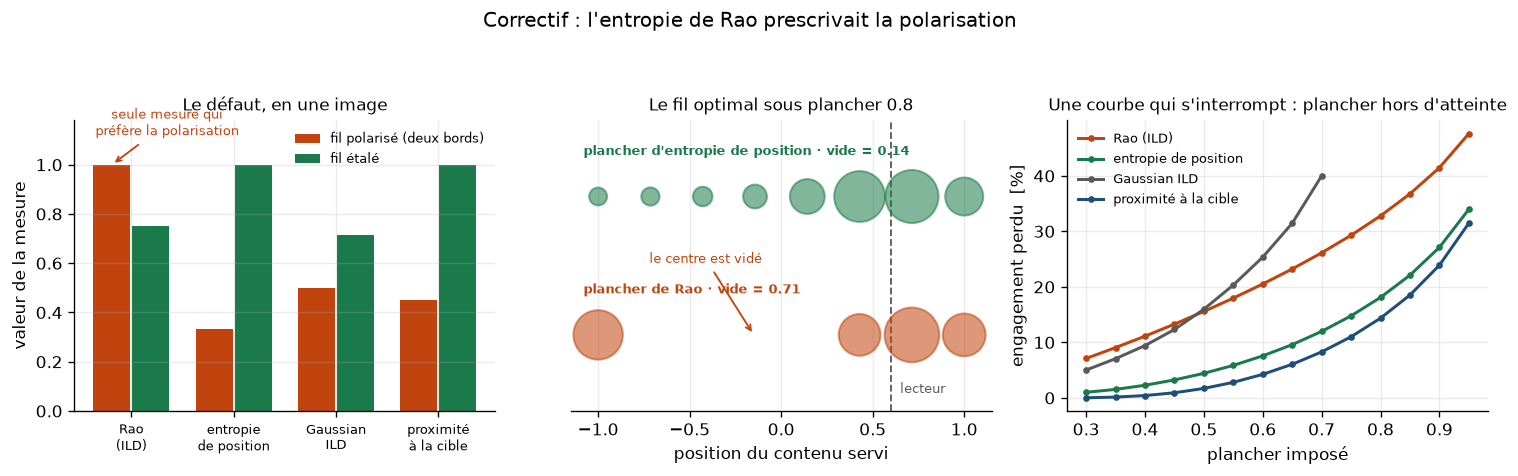

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(12.6, 4.0))
verdicts, shapes, costs = axes

# (a) Ce que chaque mesure pense du fil polarisé.
names = list(MEASURES)
polarised = [MEASURES[n](bimodal, CATALOGUE) for n in names]
spread = [MEASURES[n](uniform, CATALOGUE) for n in names]
positions = np.arange(len(names))
verdicts.bar(positions - 0.19, polarised, 0.36, color=PALETTE["disorder"],
             label="fil polarisé (deux bords)")
verdicts.bar(positions + 0.19, spread, 0.36, color=PALETTE["remedy"], label="fil étalé")
verdicts.set_xticks(positions)
verdicts.set_xticklabels(["Rao\n(ILD)", "entropie\nde position", "Gaussian\nILD",
                          "proximité\nà la cible"], fontsize=7.5)
verdicts.set_ylabel("valeur de la mesure")
verdicts.set_ylim(0, 1.18)
verdicts.annotate("seule mesure qui\npréfère la polarisation", xy=(-0.19, 1.0),
                  xytext=(0.35, 1.12), fontsize=7.5, color=PALETTE["disorder"],
                  ha="center", arrowprops={"arrowstyle": "->",
                                           "color": PALETTE["disorder"], "lw": 1.1})
verdicts.set_title("Le défaut, en une image", fontsize=10)
verdicts.legend(fontsize=7.5, loc="upper right", framealpha=0.95)

# (b) Le fil que chaque plancher fait servir.
FLOOR_SHAPE = 0.8
for row, (key, label, colour) in enumerate(
    (("Rao (ILD)", "plancher de Rao", PALETTE["disorder"]),
     ("entropie de position", "plancher d'entropie de position", PALETTE["remedy"]))
):
    feed = optimal_feed_under(MEASURES[key], VIEWPOINTS, USER, FLOOR_SHAPE, width=WIDTH)
    # Seuls les points de vue réellement servis sont tracés : une masse sous le seuil du
    # diagnostic n'est pas une exposition, et la dessiner masquerait le vide qu'elle laisse.
    shown = feed.weights > 0.01
    shapes.scatter(feed.positions[shown], np.full(int(shown.sum()), row),
                   s=60 + 3000 * feed.weights[shown], color=colour, alpha=0.55,
                   edgecolors=colour, linewidths=1.2, zorder=3)
    shapes.text(-1.08, row + 0.30, f"{label} · vide = {feed.largest_gap:.2f}",
                fontsize=8, color=colour, fontweight="bold")
shapes.axvline(USER, color=PALETTE["neutral"], linestyle="--", linewidth=1.1)
shapes.text(USER + 0.05, -0.42, "lecteur", fontsize=8, color=PALETTE["neutral"])
shapes.annotate("le centre est vidé", xy=(-0.15, 0.0), xytext=(-0.72, 0.52), fontsize=8,
                color=PALETTE["disorder"],
                arrowprops={"arrowstyle": "->", "color": PALETTE["disorder"], "lw": 1.1})
shapes.set_xlim(-1.15, 1.15)
shapes.set_ylim(-0.55, 1.55)
shapes.set_yticks([])
shapes.set_xlabel("position du contenu servi")
shapes.set_title(f"Le fil optimal sous plancher {FLOOR_SHAPE:.1f}", fontsize=10)
shapes.spines["left"].set_visible(False)

# (c) Ce que chaque norme coûte, et jusqu'où elle se laisse imposer.
grid = np.linspace(0.3, 0.95, 14)
palette = [PALETTE["disorder"], PALETTE["remedy"], PALETTE["neutral"], PALETTE["order"]]
for name, colour in zip(names, palette, strict=True):
    curve = []
    for floor in grid:
        feed = optimal_feed_under(MEASURES[name], VIEWPOINTS, USER, float(floor), width=WIDTH)
        complies = MEASURES[name](feed.weights, feed.positions) >= floor - 1e-6
        curve.append(100 * (1 - feed.engagement / free) if complies else np.nan)
    costs.plot(grid, curve, color=colour, linewidth=1.8, marker="o", markersize=3, label=name)
costs.set_xlabel("plancher imposé")
costs.set_ylabel("engagement perdu  [%]")
costs.set_title("Une courbe qui s'interrompt : plancher hors d'atteinte", fontsize=10)
costs.legend(fontsize=7.5)

figure.suptitle("Correctif : l'entropie de Rao prescrivait la polarisation", fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.92))
save_figure(figure, "fig13b_correctif_rao")
plt.show()

## 10. Ce que ce correctif change

**L'entropie de Rao est retirée de la recommandation.** Elle résiste au bourrage d'étiquettes,
mais son optimum sous contrainte est bimodal : elle prescrirait la polarisation. C'est le
deuxième correctif apporté à la recommandation 1 du mémorandum, et il porte cette fois sur le
remplacement proposé la veille.

**Ce qui la remplace :**

| Rôle | Mesure | Motif |
|---|---|---|
| **plancher** | entropie de position | garde l'interprétation de l'IDE, résiste aux trois adversaires testés, coûte moins cher que Rao |
| **publié à côté** | plus grand vide | l'entropie est nominale : elle ne voit pas la géométrie que ce diagnostic expose |
| **successeur** | proximité à une cible déclarée | seule à rendre explicite la forme d'exposition visée, au lieu de la supposer |

**Et une leçon de méthode.** L'erreur n'a pas été trouvée en relisant le code : elle a été
trouvée en lisant ce que le domaine avait déjà publié sur la mesure employée. Le test adverse
de la veille était correct dans ce qu'il réfutait, et faux dans ce qu'il proposait — parce
qu'il avait éprouvé le remplaçant contre **un seul** adversaire.

> **Une norme ne se valide pas contre l'attaque qu'on a imaginée, mais contre celles qu'on n'a
> pas imaginées.** C'est un argument pour aller chercher la littérature avant de prescrire, et
> non après.

### La limite qui subsiste

Les quatre mesures reposent sur une **projection des contenus sur un axe d'opinion**, supposé
connu et unidimensionnel. Sur données réelles, cette projection est précisément ce qui manque :
c'est l'objet du chantier suivant, et la raison pour laquelle l'évaluation sur un jeu de
données de recommandation ne peut pas se faire avec des catégories éditoriales pour points de
vue.

## Pistes ouvertes

1. **Reprendre le test sur des *embeddings* réels** plutôt que sur un axe synthétique. Le jeu
   de données MIND fournit des historiques de consultation et des catégories éditoriales : on
   pourrait y mesurer la distance sémantique effective entre contenus d'une même étiquette, et
   donc estimer le $\varphi$ dont une plateforme dispose réellement.
2. **Chiffrer le coût de production du découplage.** Le modèle le suppose nul ; s'il ne l'est
   pas, il existe un $\varphi$ d'équilibre, et c'est lui qui détermine si la manipulation est
   rentable.
3. **Étendre au jeu de Stackelberg** de la [feuille de route §4.2](../docs/feuille-de-route.md) :
   ici la plateforme optimise sous une contrainte fixée, mais le régulateur devrait anticiper
   la réponse et choisir le plancher en conséquence.
4. **Traiter le choix du catalogue de référence.** Toute la résistance de $Q$ repose sur une
   étendue fixée par le régulateur. Qui la fixe, et comment, redevient la question politique
   que l'[audit §2.1](../docs/limites.md) avait déjà posée pour $k$.